# Data Analysis for General voices 0.0.1

In [2]:
!pip install seaborn

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 10.8 MB/s eta 0:00:0000:0100:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 10.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 3.2 MB/s eta 0:00:00ta 0:00:01


In [6]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load JSON file
with open("/home/amber/Desktop/KartalOl/code/Kartalol-speech-recognition/dataset/sentences/KartalOl_general_voices_0_0_1.json", "r", encoding="utf-8") as f:
    data = json.load(f)

# Convert to DataFrame
df = pd.DataFrame(data["data"])
df.head()


,audio_filepath,duration,text
0,m1_ID473_6623_book3.wav,4.1935,پادشاه ابراهیمدن خبر آلدی کی نییه گلمیسن
1,f2_ID1000_13987_book4.wav,4.3735,بوردا آتلارین ساتدیلار بیر منزیل آلدیلار
2,f2_ID1001_14001_book4.wav,4.7735,اوتوررام اونون آناسیینان باجیسیینان اونون یاسی...
3,f2_ID1002_14015_book4.wav,3.4935,بیرتهر دولاناخ گؤرک باشیمیزا نه گلیر
4,f2_ID1003_14029_book4.wav,6.7335,بو دا گلدی گؤردو ابولقاسیمدی بو دا ساریلدی بون...


In [8]:
# Extract metadata
df["text"] = df["text"].astype(str)
df["num_words"] = df["text"].apply(lambda x: len(x.split()))
df["num_chars"] = df["text"].apply(len)
df["speaker_id"] = df["audio_filepath"].apply(lambda x: x.split(".")[0])


In [13]:
# Duration in hours
total_duration_sec = df["duration"].sum()
total_duration_hr = total_duration_sec / 3600

# Unique words
all_words = df["text"].str.split().explode()
unique_words = all_words.nunique()

# Speaker distribution
speaker_counts = df["speaker_id"].value_counts()

In [9]:
# Summary statistics
print("=== Dataset Overview ===")
print(f"Total samples: {len(df)}")
print(f"Total duration (seconds): {df['duration'].sum():.2f}")
print(f"Average duration (seconds): {df['duration'].mean():.2f}")
print(f"Average words per sentence: {df['num_words'].mean():.2f}")
print(f"Average characters per sentence: {df['num_chars'].mean():.2f}")
print(f"Total words: {df['num_words'].sum()}")
print(f"Total characters: {df['num_chars'].sum()}")

=== Dataset Overview ===
Total samples: 179175
Total duration (seconds): 1559081.79
Average duration (seconds): 8.70
Average words per sentence: 17.01
Average characters per sentence: 114.10
Total words: 3047042
Total characters: 20443880


In [14]:
# Summary
print("=== Dataset Summary ===")
print(f"Total samples: {len(df)}")
print(f"Total duration: {total_duration_sec:.2f} seconds ({total_duration_hr:.2f} hours)")
print(f"Average duration: {df['duration'].mean():.2f} seconds")
print(f"Average words per sentence: {df['num_words'].mean():.2f}")
print(f"Average characters per sentence: {df['num_chars'].mean():.2f}")
print(f"Total words: {df['num_words'].sum()}")
print(f"Unique words: {unique_words}")
print("\n=== Speaker Distribution (Top 10) ===")
print(speaker_counts.head(10))

=== Dataset Summary ===
Total samples: 179175
Total duration: 1559081.79 seconds (433.08 hours)
Average duration: 8.70 seconds
Average words per sentence: 17.01
Average characters per sentence: 114.10
Total words: 3047042
Unique words: 366153

=== Speaker Distribution (Top 10) ===
speaker_id
1713042894    2
1713109043    2
1713046938    2
1713175284    2
1713185605    2
1712995883    2
1713193914    2
1713111554    2
1713098532    2
1713117649    2
Name: count, dtype: int64


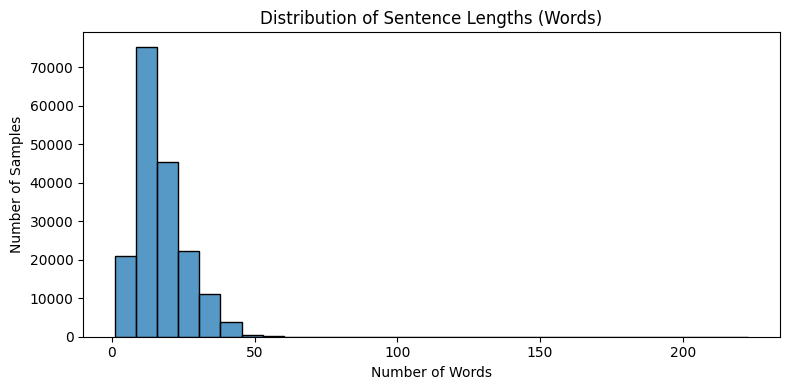

In [10]:
# Plot: Sentence length in words
plt.figure(figsize=(8, 4))
sns.histplot(df["num_words"], bins=30, kde=False)
plt.title("Distribution of Sentence Lengths (Words)")
plt.xlabel("Number of Words")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.show()

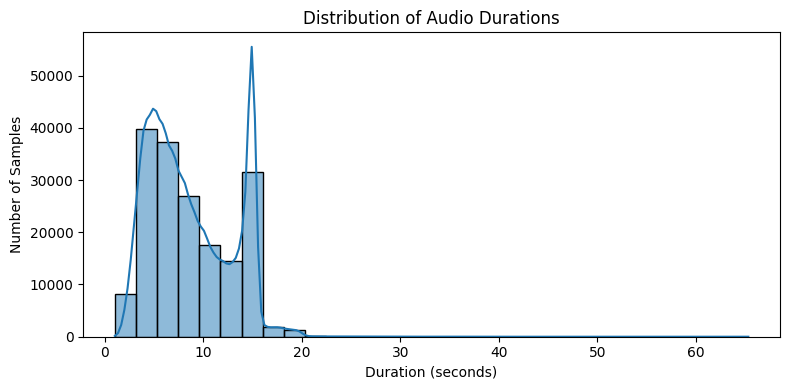

In [11]:
# Plot: Distribution of sentence durations
plt.figure(figsize=(8, 4))
sns.histplot(df["duration"], bins=30, kde=True)
plt.title("Distribution of Audio Durations")
plt.xlabel("Duration (seconds)")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.show()